In [1]:
""" <!-- Task 2: Quantitative analysis using pynance and TaLib

●	Tasks:
○	Use additional finance data
○	Load and prepare the data.
■	Load your stock price data into a pandas DataFrame. Ensure your data includes columns like Open, High, Low, Close, and Volume.	
○	Apply Analysis Indicators with TA-Lib
■	You can use TA-Lib to calculate various technical indicators such as moving averages, RSI (Relative Strength Index), and MACD (Moving Average Convergence Divergence)
○	Use PyNance for Financial Metrics
○	Visualize the Data
■	Create visualizations to better understand the data and the impact of different indicators on the stock price.
●	KPIs
○	Proactivity to self-learn - sharing references.
○	Accuracy of indicators
○	Completeness of Data Analysis

Minimum Essential To Do:
●	Merge the necessary branches from task-1 into the main branch using a Pull Request (PR)
●	Create at least one new branch called "task-2" for the ongoing development of the dashboard.
●	Commit your work with a descriptive commit message.
●	Prepare Your Data
●	Calculate Basic Technical Indicators
●	Visualize Data
 --> """

' <!-- Task 2: Quantitative analysis using pynance and TaLib\n\n●\tTasks:\n○\tUse additional finance data\n○\tLoad and prepare the data.\n■\tLoad your stock price data into a pandas DataFrame. Ensure your data includes columns like Open, High, Low, Close, and Volume.\t\n○\tApply Analysis Indicators with TA-Lib\n■\tYou can use TA-Lib to calculate various technical indicators such as moving averages, RSI (Relative Strength Index), and MACD (Moving Average Convergence Divergence)\n○\tUse PyNance for Financial Metrics\n○\tVisualize the Data\n■\tCreate visualizations to better understand the data and the impact of different indicators on the stock price.\n●\tKPIs\n○\tProactivity to self-learn - sharing references.\n○\tAccuracy of indicators\n○\tCompleteness of Data Analysis\n\nMinimum Essential To Do:\n●\tMerge the necessary branches from task-1 into the main branch using a Pull Request (PR)\n●\tCreate at least one new branch called "task-2" for the ongoing development of the dashboard.\n●\

In [2]:
""" 1. Data Preparation:
•	Load your stock price data into a pandas DataFrame. Ensure your data includes columns like Open
"""

import pandas as pd
import talib
import pynance as pn
import matplotlib.pyplot as plt

# Load your dataset (assuming a CSV from Task 1)
# Download stock data for Apple (AAPL) from 2020-01-01 to the present
df =  pd.read_csv("../data/raw/AAPL_historical_data.csv", parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Data Cleaning & Typing
df = df.dropna()
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Check for quality issues
print(f"Missing values:\n{df.isnull().sum()}")


Missing values:
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


In [3]:
""" 2. Computing Technical Indicators (TA-Lib)
TA-Lib is highly efficient because it's built on C. You will use it to generate the three primary categories of indicators: Trend, Momentum, and Volatility.
 """
# Moving Averages
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

# Relative Strength Index (RSI)
df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

# MACD (Moving Average Convergence Divergence)
# Returns: macd, signal, hist
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], fastperiod=12, slowperiod=26, signalperiod=9
)


In [4]:
""" 3. Financial Metrics with PyNance
While TA-Lib handles "technical" indicators, PyNance is often used for descriptive statistics and performance metrics like volatility and returns that are more "quantitative" than "chartist."
 """
# Example: Using PyNance to compute log returns or volatility
# PyNance often works best when you extract specific series
""" returns = pn.tech.ret(df['Close']) # Simple returns
df['Returns'] = returns """
# Simple Returns: (Price_today / Price_yesterday) - 1
df['Returns'] = df['Close'].pct_change()

# OR Log Returns (often preferred for Quant analysis):
import numpy as np
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

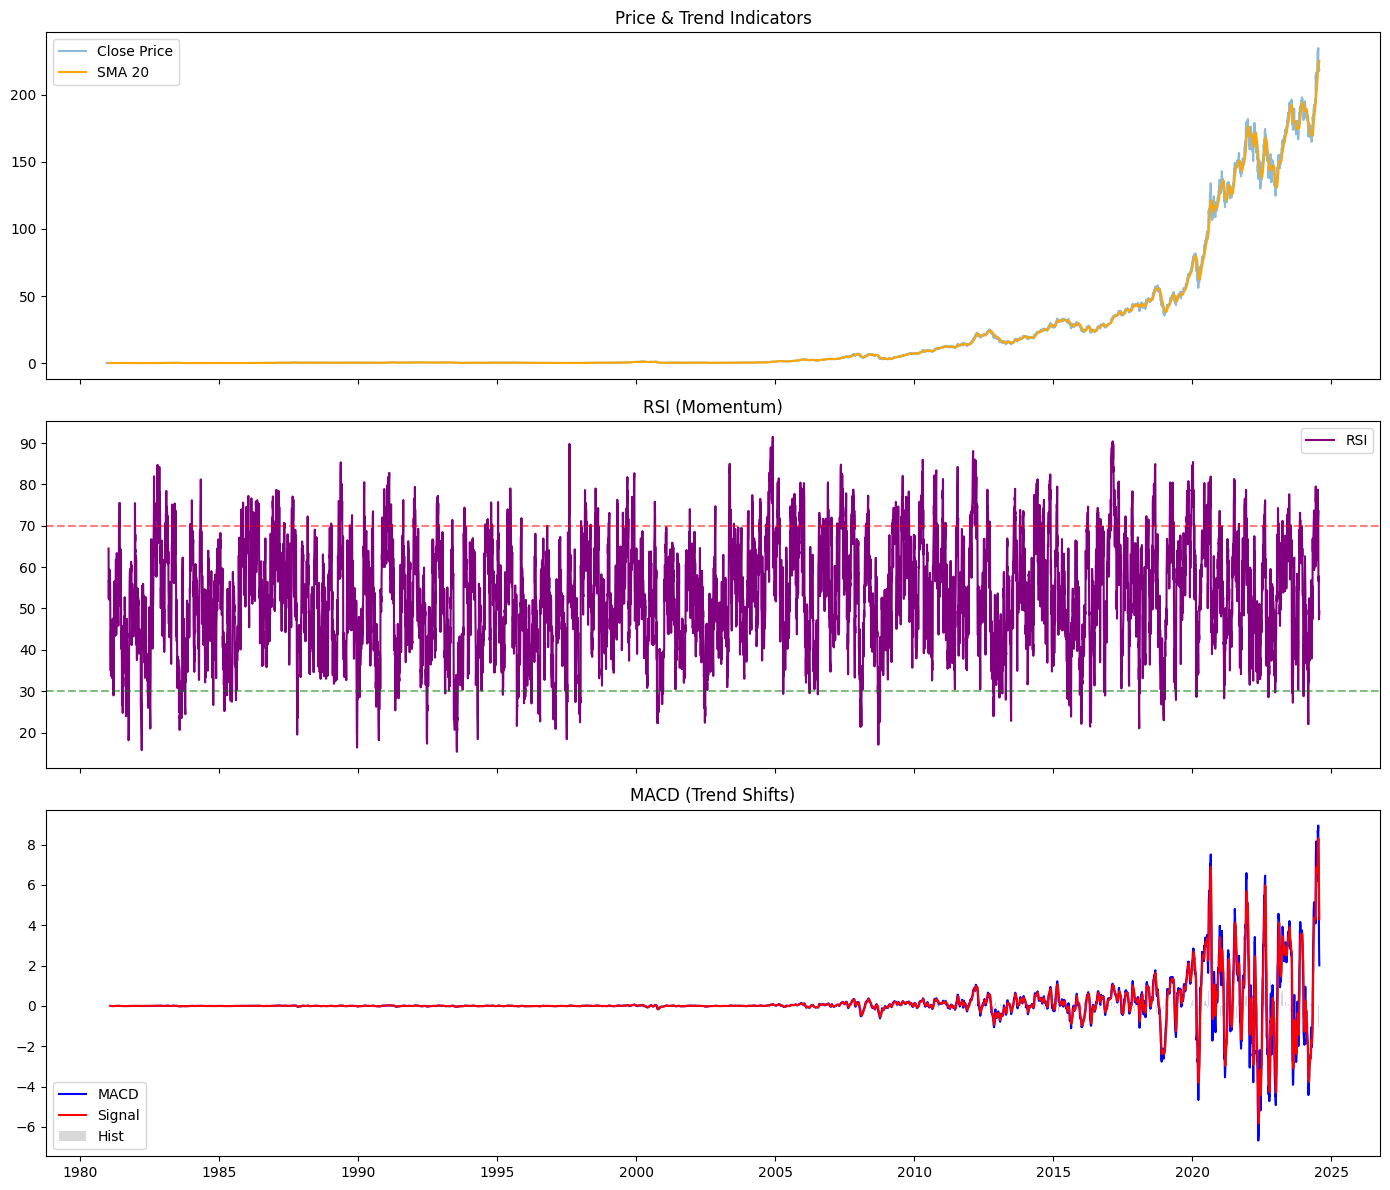

In [5]:
""" 4. Visualization
To meet the deliverable of "clear visualizations," you should use a multi-panel plot (subplots). This prevents the RSI and MACD (which have different scales) from squashing the price chart.
 """
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price and Moving Averages
ax1.plot(df.index, df['Close'], label='Close Price', alpha=0.5)
ax1.plot(df.index, df['SMA_20'], label='SMA 20', color='orange')
ax1.set_title('Price & Trend Indicators')
ax1.legend()

# Panel 2: RSI
ax2.plot(df.index, df['RSI'], label='RSI', color='purple')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5) # Overbought
ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold
ax2.set_title('RSI (Momentum)')
ax2.legend()

# Panel 3: MACD
ax3.plot(df.index, df['MACD'], label='MACD', color='blue')
ax3.plot(df.index, df['MACD_signal'], label='Signal', color='red')
ax3.bar(df.index, df['MACD_hist'], label='Hist', color='gray', alpha=0.3)
ax3.set_title('MACD (Trend Shifts)')
ax3.legend()

plt.tight_layout()
plt.show()
